# Capstone Project Module 3

## Latar Belakang
Sebuah perusahaan supermarket memiliki data pelanggan yang mencakup informasi demografi, pendapatan, riwayat pembelian produk, aktivitas pembelian pada beberapa channel, respon pelanggan terhadap campaign promosi, sampai komplain.

Dalam bisnis retail, memahami perilaku pelanggan sangat penting karena perlu mengetahui pelanggan mana yang memberikan kontribusi revenue terbesar, produk apa yang paling diminati, channel pembelian mana yang paling efektif, dan target customer seperti apa yang lebih mungkin menerima campaign.

## Perumusan Masalah
Perusahaan perlu memahami karakteristik pelanggan yang valuable dan faktor yang berkaitan dengan keberhasilan campaign promosi.

### Pertanyaan Analisis
1. Bagaimana karakteristik pelanggan supermarket berdasarkan demografi?
2. Produk apa yang menjadi kontributor spending terbesar?
3. Channel pembelian mana yang paling sering digunakan pelanggan?
4. Apakah customer dengan karakteristik tertentu lebih cenderung menerima campaign terakhir?
5. Bagaimana perilaku pelanggan berdasarkan recency, discount purchases, dan complain?
6. Segmentasi customer seperti apa yang dapat digunakan untuk strategi marketing?
7. Rekomendasi bisnis apa yang dapat diberikan?

## Tujuan Analisis
1. Memahami profil pelanggan supermarket.
2. Mengidentifikasi produk dengan kontribusi spending terbesar.
3. Menganalisis perilaku pembelian berdasarkan channel.
4. Mengevaluasi efektivitas campaign berdasarkan response pelanggan.
5. Membuat segmentasi customer berdasarkan spending dan recency.
6. Memberikan insight dan actionable recommendation untuk stakeholder.

## Data

Untuk menjawab pertanyaan analisis di atas, kita akan menganalisa data pelanggan supermarket yang sudah dikumpulkan oleh perusahaan. [Dataset dapat diakses di sini](https://drive.google.com/drive/folders/1WodnBbuYTvsF0-6HTuQABQ0KCS31lqbK)

## Data Dictionary
### People
- ID, Year_Birth, Education, Marital_Status, Income, Kidhome, Teenhome, Dt_Customer, Recency, Complain
### Products
- MntWines, MntFruits, MntMeatProducts, MntFishProducts, MntSweetProducts, MntGoldProds
### Promotion
- NumDealsPurchases, AcceptedCmp1 sampai AcceptedCmp5, Response
### Place
- NumWebPurchases, NumCatalogPurchases, NumStorePurchases, NumWebVisitsMonth

# Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import normaltest, mannwhitneyu, chi2_contingency, kruskal
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
sns.set_theme(style='whitegrid')

# Load Dataset

In [4]:
df = pd.read_csv('Supermarket Customers.csv', sep='\t')

# Data Understanding

In [5]:
print(f'Jumlah baris: {df.shape[0]}')
print(f'Jumlah kolom: {df.shape[1]}')

Jumlah baris: 2240
Jumlah kolom: 29


In [11]:
df.info()

# ringkasan struktur DataFrame

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [12]:
df.describe()

# menampilkan statistik deskriptif dari kolom numerik

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [14]:
df.describe(include='object')

# menampilkan statistik deskriptif khusus kolom kategorikal / text

,Education,Marital_Status,Dt_Customer
count,2240,2240,2240
unique,5,8,663
top,Graduation,Married,31-08-2012
freq,1127,864,12


## Validasi Kolom Berdasarkan Data Dictionary
Bagian ini memastikan kolom yang ada pada dataset sesuai dengan definisi data dictionary.

In [15]:
data_dictionary = {
    'ID': 'Customer unique identifier',
    'Year_Birth': 'Customer birth year',
    'Education': 'Customer education level',
    'Marital_Status': 'Customer marital status',
    'Income': 'Customer yearly household income',
    'Kidhome': 'Number of children in household',
    'Teenhome': 'Number of teenagers in household',
    'Dt_Customer': 'Date of customer enrollment',
    'Recency': 'Number of days since last purchase',
    'Complain': 'Customer complained in last 2 years',
    'MntWines': 'Amount spent on wine',
    'MntFruits': 'Amount spent on fruits',
    'MntMeatProducts': 'Amount spent on meat',
    'MntFishProducts': 'Amount spent on fish',
    'MntSweetProducts': 'Amount spent on sweets',
    'MntGoldProds': 'Amount spent on gold products',
    'NumDealsPurchases': 'Number of discount purchases',
    'AcceptedCmp1': 'Accepted campaign 1',
    'AcceptedCmp2': 'Accepted campaign 2',
    'AcceptedCmp3': 'Accepted campaign 3',
    'AcceptedCmp4': 'Accepted campaign 4',
    'AcceptedCmp5': 'Accepted campaign 5',
    'Response': 'Accepted last campaign',
    'NumWebPurchases': 'Purchases through website',
    'NumCatalogPurchases': 'Purchases using catalog',
    'NumStorePurchases': 'Purchases directly in store',
    'NumWebVisitsMonth': 'Website visits last month'
}
dict_df = pd.DataFrame(data_dictionary.items(), columns=['Column', 'Description'])
dict_df['Available in Dataset'] = dict_df['Column'].isin(df.columns)
dict_df

,Column,Description,Available in Dataset
0,ID,Customer unique identifier,True
1,Year_Birth,Customer birth year,True
2,Education,Customer education level,True
3,Marital_Status,Customer marital status,True
4,Income,Customer yearly household income,True
5,Kidhome,Number of children in household,True
6,Teenhome,Number of teenagers in household,True
7,Dt_Customer,Date of customer enrollment,True
8,Recency,Number of days since last purchase,True
9,Complain,Customer complained in last 2 years,True


In [16]:
list_item = []
for col in df.columns:
    list_item.append([col, df[col].nunique(), df[col].unique()[:10]])
unique_table = pd.DataFrame(list_item, columns=['Column Name', 'Number of Unique', 'Unique Sample'])
unique_table

,Column Name,Number of Unique,Unique Sample
0,ID,2240,"[5524, 2174, 4141, 6182, 5324, 7446, 965, 6177, 4855, 5899]"
1,Year_Birth,59,"[1957, 1954, 1965, 1984, 1981, 1967, 1971, 1985, 1974, 1950]"
2,Education,5,"[Graduation, PhD, Master, Basic, 2n Cycle]"
3,Marital_Status,8,"[Single, Together, Married, Divorced, Widow, Alone, Absurd, YOLO]"
4,Income,1974,"[58138.0, 46344.0, 71613.0, 26646.0, 58293.0, 62513.0, 55635.0, 33454.0, 30351.0, 5648.0]"
5,Kidhome,3,"[0, 1, 2]"
6,Teenhome,3,"[0, 1, 2]"
7,Dt_Customer,663,"[04-09-2012, 08-03-2014, 21-08-2013, 10-02-2014, 19-01-2014, 09-09-2013, 13-11-2012, 08-05-2013, 06-06-2013, 13-03-2014]"
8,Recency,100,"[58, 38, 26, 94, 16, 34, 32, 19, 68, 11]"
9,MntWines,776,"[635, 11, 426, 173, 520, 235, 76, 14, 28, 5]"


Observasi awal:
1. ID merupakan identifier unik pelanggan.
2. Beberapa kolom income memiliki missing value.
3. Dt_Customer masih bertipe object.
4. Z_CostContact dan Z_Revenue kemungkinan kolom konstan.
5. Year_Birth akan lebih mudah dianalisis jika diubah menjadi Umur.

# Data Cleaning

## Missing Value

In [17]:
missing_value = pd.DataFrame({'Missing Value': df.isna().sum(), 'Percentage (%)': round(df.isna().sum() / len(df) * 100, 2)})
missing_value[missing_value['Missing Value'] > 0]

,Missing Value,Percentage (%)
Income,24,1.07


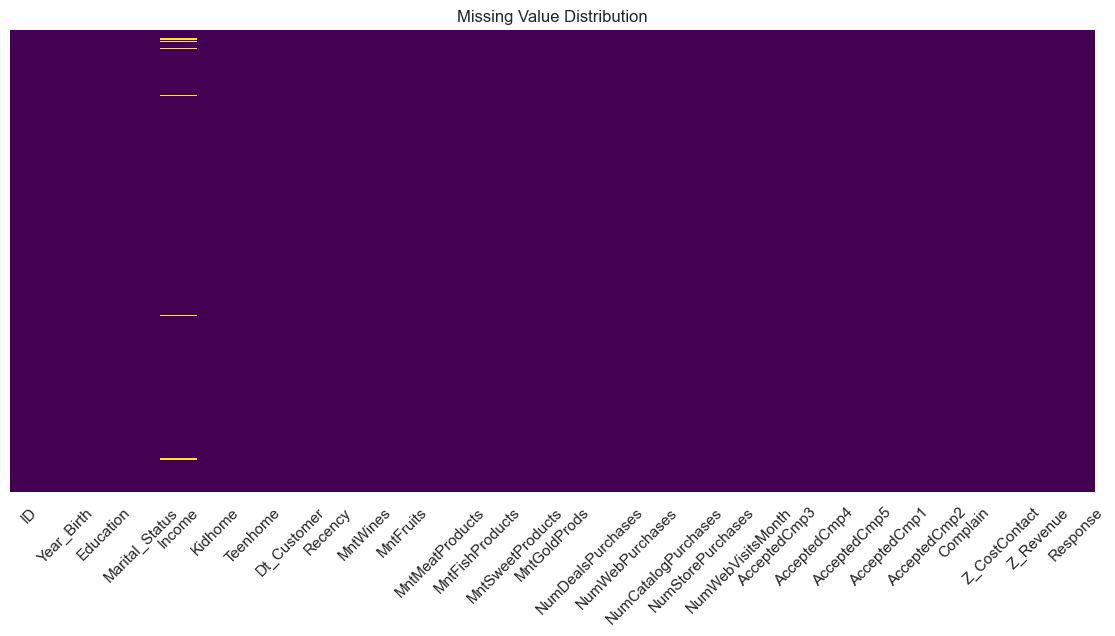

In [20]:
plt.figure(figsize=(14,6))

sns.heatmap(
    df.isnull(),
    yticklabels=False,
    cbar=False,
    cmap='viridis'
)

plt.title('Missing Value Distribution')
plt.xticks(rotation=45)
plt.show()

Missing value terdapat pada Income. Karena Income adalah data numerik yang berpotensi memiliki outlier, imputasi menggunakan median lebih sesuai dibanding mean.

In [21]:
income_median = df['Income'].median()
df['Income'] = df['Income'].fillna(income_median)
print(f'Missing value pada Income diisi dengan median: {income_median}')
print(f'Total missing value setelah handling: {df.isna().sum().sum()}')

Missing value pada Income diisi dengan median: 51381.5
Total missing value setelah handling: 0


## Duplicate Data

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df = df.drop_duplicates()
print(f'Jumlah baris setelah duplicate handling: {df.shape[0]}')

Jumlah baris setelah duplicate handling: 2240


## Data Formatting

In [25]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)
df[['Dt_Customer']].head()

,Dt_Customer
0,2012-09-04
1,2014-03-08
2,2013-08-21
3,2014-02-10
4,2014-01-19


## Constant Columns

In [26]:
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
constant_cols

['Z_CostContact', 'Z_Revenue']

In [27]:
df = df.drop(columns=constant_cols)
print(f'Kolom yang dihapus: {constant_cols}')
print(f'Jumlah kolom setelah penghapusan: {df.shape[1]}')

Kolom yang dihapus: ['Z_CostContact', 'Z_Revenue']
Jumlah kolom setelah penghapusan: 27


# Feature Engineering

In [28]:
analysis_year = 2026
df['Age'] = analysis_year - df['Year_Birth']
df['Total_Children'] = df['Kidhome'] + df['Teenhome']
product_cols = ['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']
df['Total_Spending'] = df[product_cols].sum(axis=1)
purchase_cols = ['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']
df['Total_Purchases'] = df[purchase_cols].sum(axis=1)
latest_date = df['Dt_Customer'].max()
df['Customer_Tenure_Days'] = (latest_date - df['Dt_Customer']).dt.days
campaign_cols = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5']
df['Total_Accepted_Campaign'] = df[campaign_cols].sum(axis=1)
df[['Age', 'Total_Children', 'Total_Spending', 'Total_Purchases', 'Customer_Tenure_Days', 'Total_Accepted_Campaign']].head()

,Age,Total_Children,Total_Spending,Total_Purchases,Customer_Tenure_Days,Total_Accepted_Campaign
0,69,0,1617,22,663,0
1,72,2,27,4,113,0
2,61,0,776,20,312,0
3,42,1,53,6,139,0
4,45,1,422,14,161,0


## Simplifying Marital Status

In [29]:
df['Marital_Status_Clean'] = df['Marital_Status'].replace({
    'Married': 'Relationship', 'Together': 'Relationship', 'Single': 'Single',
    'Divorced': 'Previously Married', 'Widow': 'Previously Married',
    'Alone': 'Other', 'Absurd': 'Other', 'YOLO': 'Other'
})
df['Marital_Status_Clean'].value_counts()

Marital_Status_Clean
Relationship          1444
Single                 480
Previously Married     309
Other                    7
Name: count, dtype: int64

## Customer Value Segment

In [30]:
q1 = df['Total_Spending'].quantile(0.25)
q3 = df['Total_Spending'].quantile(0.75)
def spending_segment(x):
    if x <= q1:
        return 'Low Value'
    elif x >= q3:
        return 'High Value'
    else:
        return 'Medium Value'
df['Customer_Value_Segment'] = df['Total_Spending'].apply(spending_segment)
df['Customer_Value_Segment'].value_counts()

Customer_Value_Segment
Medium Value    1120
High Value       560
Low Value        560
Name: count, dtype: int64

## Recency Segment

In [31]:
def recency_segment(x):
    if x <= 30:
        return 'Active'
    elif x <= 90:
        return 'Warm'
    else:
        return 'Inactive'
df['Recency_Segment'] = df['Recency'].apply(recency_segment)
df['Recency_Segment'].value_counts()

Recency_Segment
Warm        1318
Active       724
Inactive     198
Name: count, dtype: int64

# Outlier Analysis

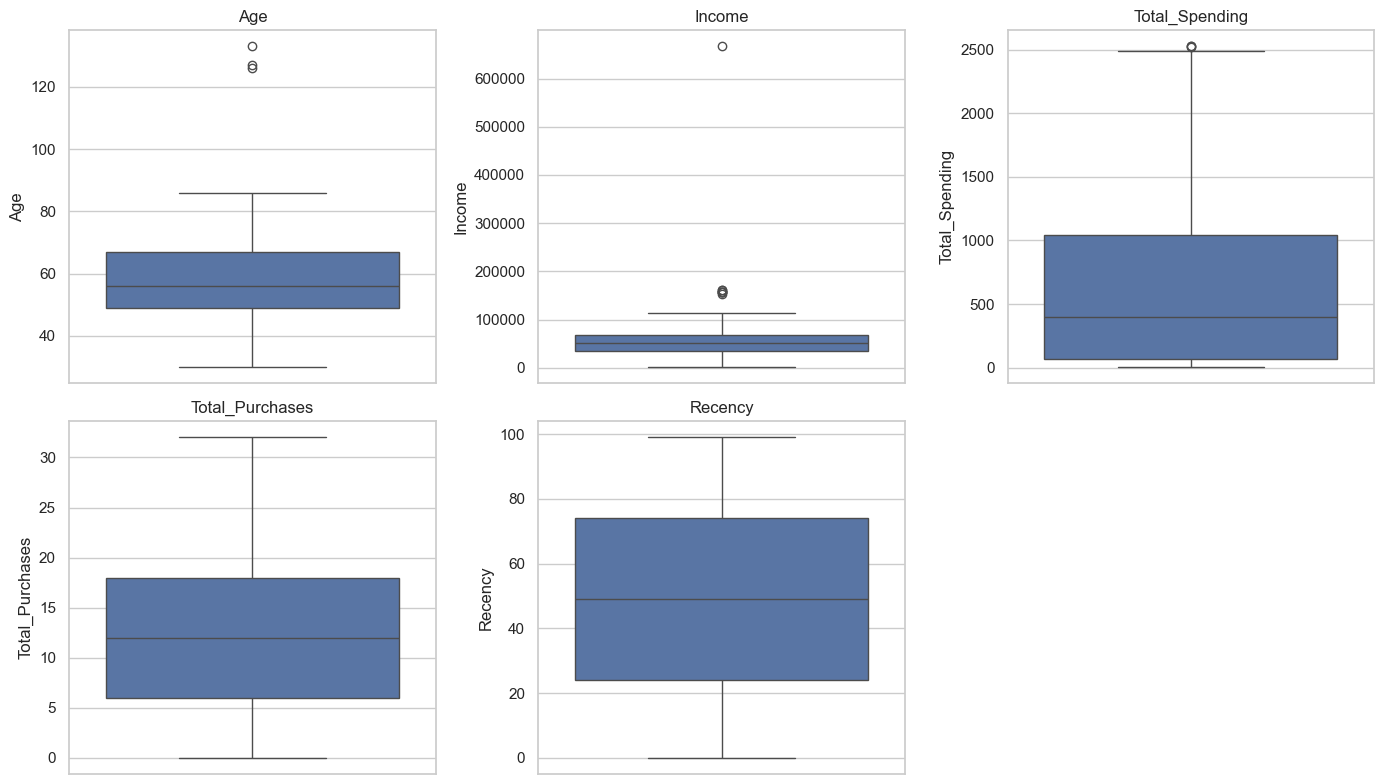

In [32]:
num_check_cols = ['Age', 'Income', 'Total_Spending', 'Total_Purchases', 'Recency']
plt.figure(figsize=(14, 8))
for i, col in enumerate(num_check_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [33]:
def outlier_summary(data, columns):
    result = []
    for col in columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
        result.append([col, lower_bound, upper_bound, len(outliers), round(len(outliers) / len(data) * 100, 2)])
    return pd.DataFrame(result, columns=['Column', 'Lower Bound', 'Upper Bound', 'Outlier Count', 'Outlier Percentage'])
outlier_summary(df, num_check_cols)

,Column,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,Age,22.000,94.000,3,0.13
1,Income,-13587.750,117416.250,8,0.36
2,Total_Spending,-1396.375,2510.625,3,0.13
3,Total_Purchases,-12.000,36.000,0,0.00
4,Recency,-51.000,149.000,0,0.00


Keputusan: Age di atas 100 dianggap tidak realistis dan dihapus. Outlier Total_Spending dan Income tidak langsung dihapus karena dapat merepresentasikan premium/high-value customer.

In [34]:
df.sort_values('Age', ascending=False)[['ID', 'Year_Birth', 'Age', 'Income', 'Total_Spending']].head(10)

,ID,Year_Birth,Age,Income,Total_Spending
239,11004,1893,133,60182.0,22
339,1150,1899,127,83532.0,1853
192,7829,1900,126,36640.0,65
1950,6663,1940,86,51141.0,157
424,6932,1941,85,93027.0,2119
894,8800,1943,83,48948.0,902
1923,4994,1943,83,77598.0,1735
358,6142,1943,83,65073.0,900
39,2968,1943,83,48948.0,902
1150,1453,1943,83,57513.0,1060


In [35]:
df = df[df['Age'] <= 100]
print(f'Jumlah baris setelah menghapus age outlier: {df.shape[0]}')

Jumlah baris setelah menghapus age outlier: 2237


In [36]:
df.sort_values('Income', ascending=False)[['ID', 'Age', 'Education', 'Income', 'Total_Spending', 'Response']].head(10)

,ID,Age,Education,Income,Total_Spending,Response
2233,9432,49,Graduation,666666.0,62,0
617,1503,50,PhD,162397.0,107,0
687,1501,44,PhD,160803.0,1717,0
1300,5336,55,Master,157733.0,59,0
164,8475,53,PhD,157243.0,1608,0
1653,4931,49,Graduation,157146.0,1730,0
2132,11181,77,PhD,156924.0,8,0
655,5555,51,Graduation,153924.0,6,0
1898,4619,81,PhD,113734.0,277,0
646,4611,56,Graduation,105471.0,1724,1


# Clean Dataset Overview

In [37]:
print(f'Jumlah baris dan kolom setelah cleaning: {df.shape}')
display(df.head())

Jumlah baris dan kolom setelah cleaning: (2237, 36)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Total_Children,Total_Spending,Total_Purchases,Customer_Tenure_Days,Total_Accepted_Campaign,Marital_Status_Clean,Customer_Value_Segment,Recency_Segment
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,69,0,1617,22,663,0,Single,High Value,Warm
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,72,2,27,4,113,0,Single,Low Value,Warm
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,61,0,776,20,312,0,Relationship,Medium Value,Active
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,42,1,53,6,139,0,Relationship,Low Value,Active
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,45,1,422,14,161,0,Relationship,Medium Value,Inactive


In [38]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
ID,2237.0,5590.726419,0.0,2829.0,5455.0,8427.0,11191.0,3245.118591
Year_Birth,2237.0,1968.901654,1940.0,1959.0,1970.0,1977.0,1996.0,11.701917
Income,2237.0,52227.407689,1730.0,35523.0,51381.5,68281.0,666666.0,25043.26683
Kidhome,2237.0,0.444345,0.0,0.0,0.0,1.0,2.0,0.538467
Teenhome,2237.0,0.506482,0.0,0.0,0.0,1.0,2.0,0.544593
Dt_Customer,2237,2013-07-10 05:01:54.260169,2012-07-30 00:00:00,2013-01-16 00:00:00,2013-07-08 00:00:00,2013-12-30 00:00:00,2014-06-29 00:00:00,NaN
Recency,2237.0,49.104604,0.0,24.0,49.0,74.0,99.0,28.956073
MntWines,2237.0,303.99553,0.0,24.0,174.0,504.0,1493.0,336.574382
MntFruits,2237.0,26.270451,0.0,1.0,8.0,33.0,199.0,39.715972
MntMeatProducts,2237.0,166.916853,0.0,16.0,67.0,232.0,1725.0,225.661158


# Exploratory Data Analysis

# 1. Customer Demographic Analysis
Analisis demografi digunakan untuk memahami profil dasar pelanggan.

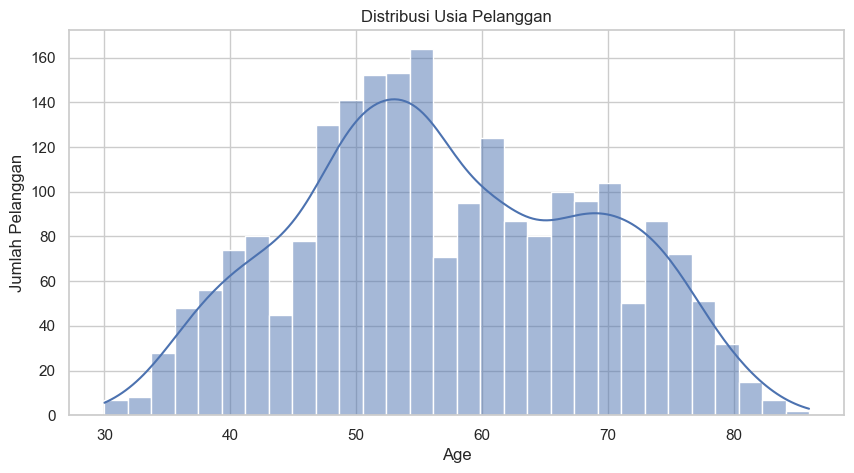

In [39]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Distribusi Usia Pelanggan')
plt.xlabel('Age')
plt.ylabel('Jumlah Pelanggan')
plt.show()

In [40]:
df['Age'].describe()

count    2237.000000
mean       57.098346
std        11.701917
min        30.000000
25%        49.000000
50%        56.000000
75%        67.000000
max        86.000000
Name: Age, dtype: float64

### Insight
Distribusi usia membantu perusahaan memahami kelompok usia dominan pelanggan.

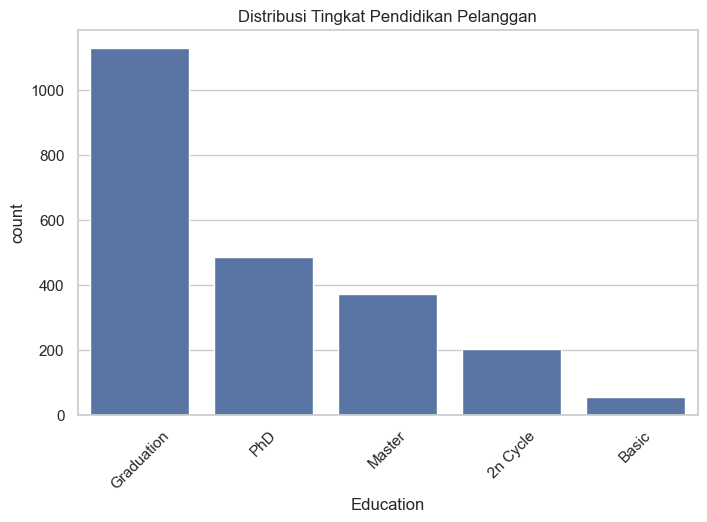

In [41]:
plt.figure(figsize=(8, 5))
order = df['Education'].value_counts().index
sns.countplot(data=df, x='Education', order=order)
plt.title('Distribusi Tingkat Pendidikan Pelanggan')
plt.xticks(rotation=45)
plt.show()

In [42]:
df['Education'].value_counts(normalize=True).mul(100).round(2)

Education
Graduation    50.38
PhD           21.68
Master        16.54
2n Cycle       8.99
Basic          2.41
Name: proportion, dtype: float64

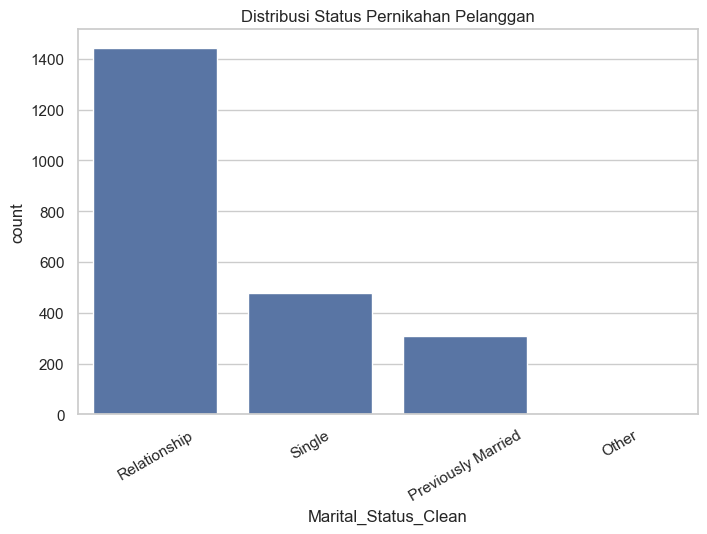

In [43]:
plt.figure(figsize=(8, 5))
order = df['Marital_Status_Clean'].value_counts().index
sns.countplot(data=df, x='Marital_Status_Clean', order=order)
plt.title('Distribusi Status Pernikahan Pelanggan')
plt.xticks(rotation=30)
plt.show()

In [44]:
df['Marital_Status_Clean'].value_counts(normalize=True).mul(100).round(2)

Marital_Status_Clean
Relationship          64.51
Single                21.41
Previously Married    13.77
Other                  0.31
Name: proportion, dtype: float64

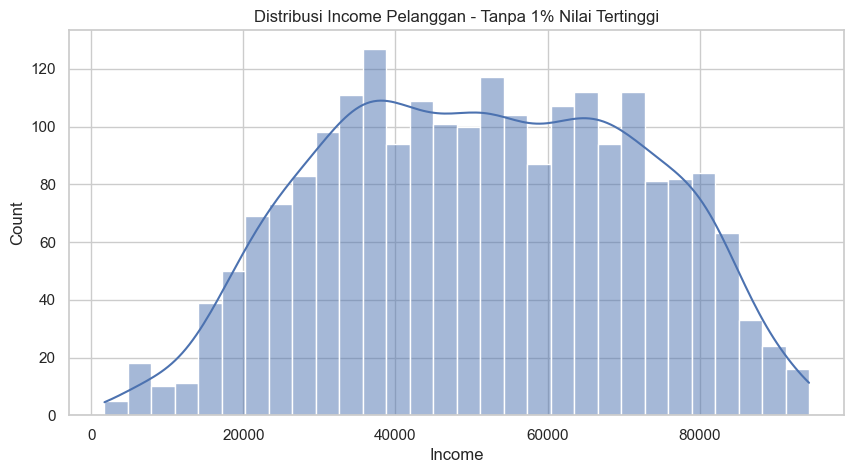

In [45]:
plt.figure(figsize=(10, 5))
sns.histplot(df[df['Income'] < df['Income'].quantile(0.99)]['Income'], bins=30, kde=True)
plt.title('Distribusi Income Pelanggan - Tanpa 1% Nilai Tertinggi')
plt.show()

In [46]:
df['Income'].describe()

count      2237.000000
mean      52227.407689
std       25043.266830
min        1730.000000
25%       35523.000000
50%       51381.500000
75%       68281.000000
max      666666.000000
Name: Income, dtype: float64

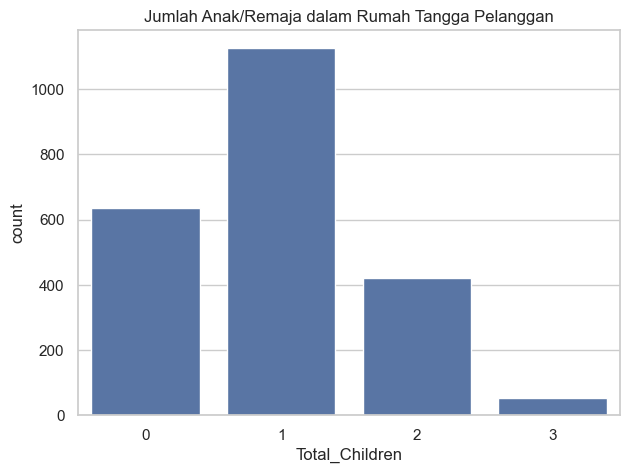

In [47]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Total_Children')
plt.title('Jumlah Anak/Remaja dalam Rumah Tangga Pelanggan')
plt.show()

### Interim Insight
Hasil visualisasi pada bagian ini digunakan sebagai dasar untuk insight bisnis dan rekomendasi di akhir notebook.

# 2. Spending Analysis
Analisis spending digunakan untuk melihat customer value dan pola pengeluaran.

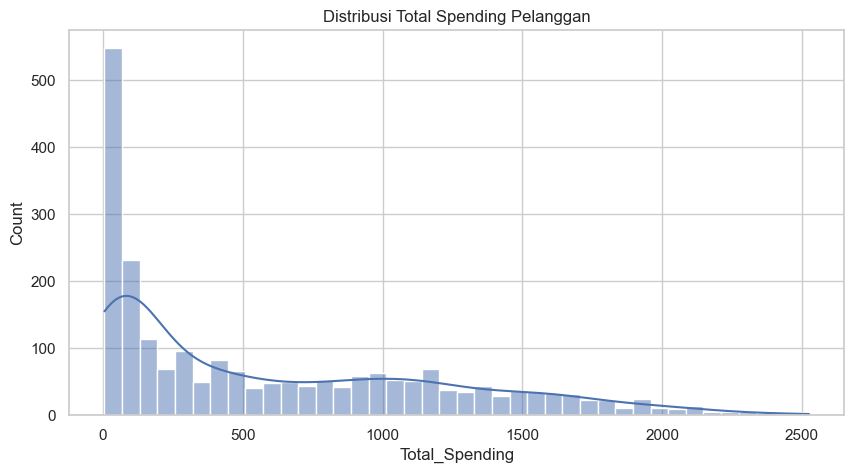

In [48]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Total_Spending'], bins=40, kde=True)
plt.title('Distribusi Total Spending Pelanggan')
plt.show()

In [49]:
df['Total_Spending'].describe()

count    2237.000000
mean      605.743406
std       601.840466
min         5.000000
25%        69.000000
50%       396.000000
75%      1045.000000
max      2525.000000
Name: Total_Spending, dtype: float64

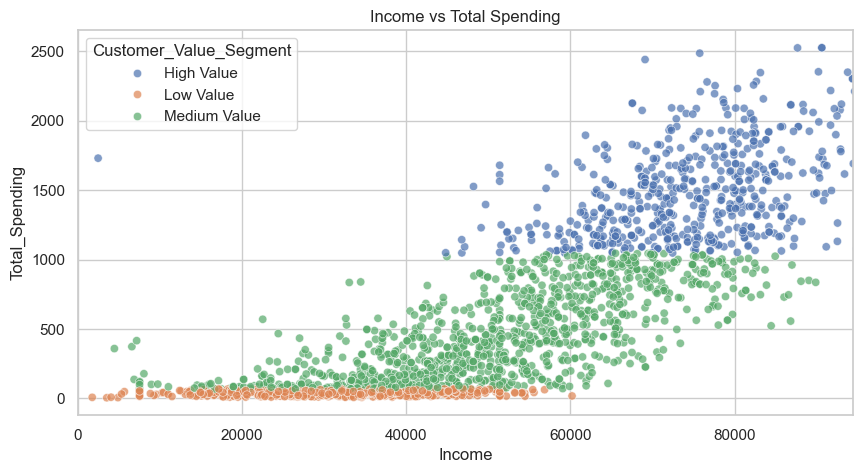

In [50]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Income', y='Total_Spending', hue='Customer_Value_Segment', alpha=0.7)
plt.xlim(0, df['Income'].quantile(0.99))
plt.title('Income vs Total Spending')
plt.show()

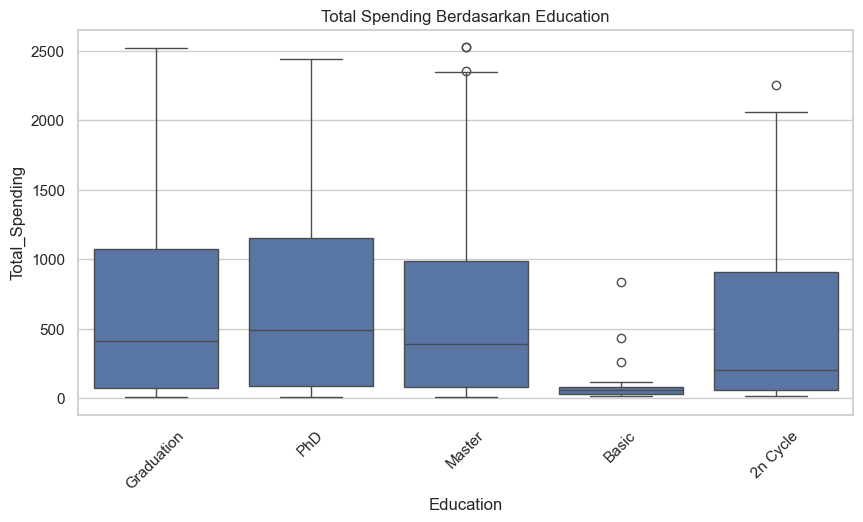

In [51]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Education', y='Total_Spending')
plt.title('Total Spending Berdasarkan Education')
plt.xticks(rotation=45)
plt.show()

In [52]:
df.groupby('Education')['Total_Spending'].agg(['count', 'mean', 'median']).sort_values('median', ascending=False)

,count,mean,median
Education,,,
PhD,485,669.975258,493.0
Graduation,1127,619.898846,414.0
Master,370,611.781081,387.5
2n Cycle,201,501.034826,205.0
Basic,54,81.796296,57.0


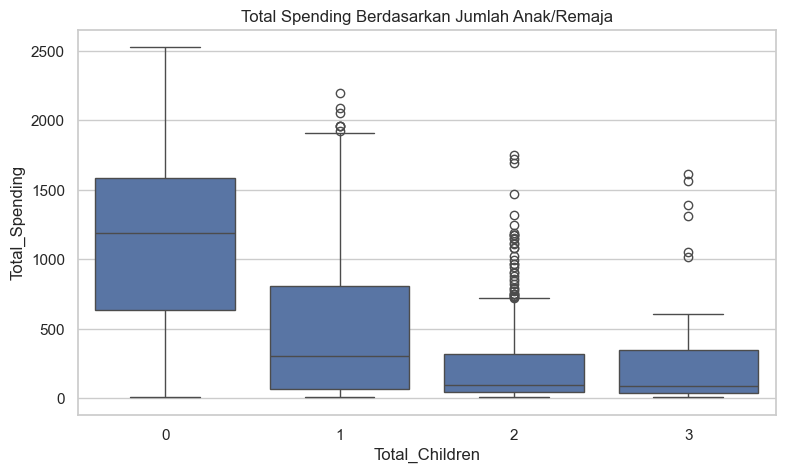

In [53]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='Total_Children', y='Total_Spending')
plt.title('Total Spending Berdasarkan Jumlah Anak/Remaja')
plt.show()

In [54]:
df.groupby('Total_Children')['Total_Spending'].agg(['count', 'mean', 'median']).sort_values('median', ascending=False)

,count,mean,median
Total_Children,,,
0,637,1104.857143,1189.0
1,1126,473.495560,306.0
2,421,245.947743,93.0
3,53,274.603774,88.0


### Interim Insight
Hasil visualisasi pada bagian ini digunakan sebagai dasar untuk insight bisnis dan rekomendasi di akhir notebook.

# 3. Product Category Analysis
Analisis ini bertujuan mengetahui kategori produk dengan kontribusi spending terbesar.

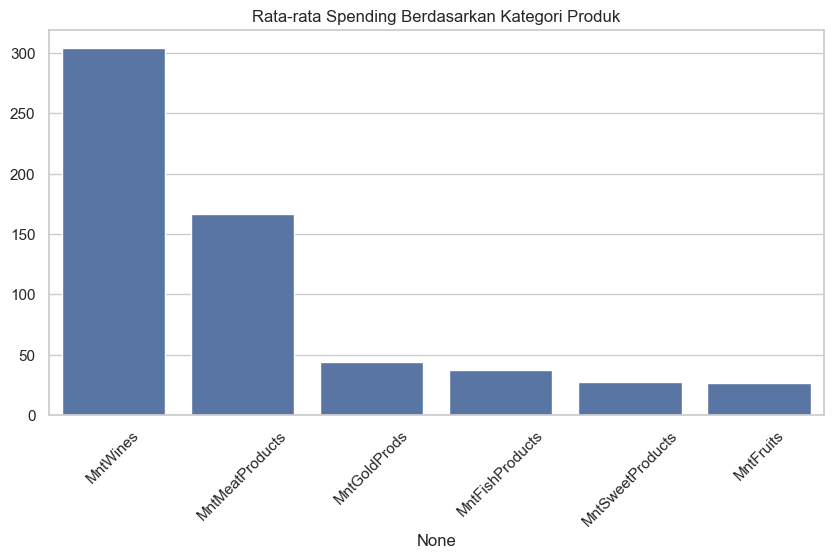

MntWines            303.995530
MntMeatProducts     166.916853
MntGoldProds         43.968708
MntFishProducts      37.523022
MntSweetProducts     27.068842
MntFruits            26.270451
dtype: float64

In [55]:
avg_product_spending = df[product_cols].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=avg_product_spending.index, y=avg_product_spending.values)
plt.title('Rata-rata Spending Berdasarkan Kategori Produk')
plt.xticks(rotation=45)
plt.show()
avg_product_spending

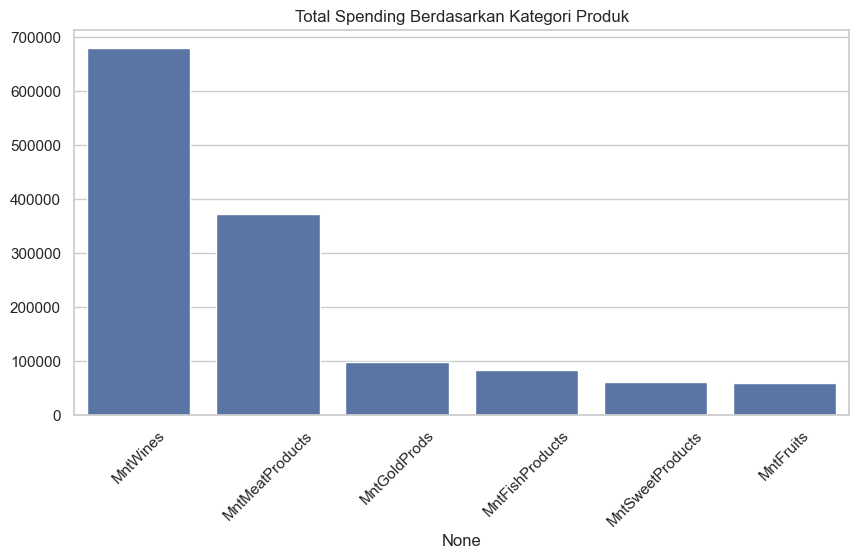

MntWines            680038
MntMeatProducts     373393
MntGoldProds         98358
MntFishProducts      83939
MntSweetProducts     60553
MntFruits            58767
dtype: int64

In [56]:
product_total = df[product_cols].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=product_total.index, y=product_total.values)
plt.title('Total Spending Berdasarkan Kategori Produk')
plt.xticks(rotation=45)
plt.show()
product_total

In [57]:
product_by_segment = df.groupby('Customer_Value_Segment')[product_cols].mean().loc[['Low Value', 'Medium Value', 'High Value']]
product_by_segment

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
Customer_Value_Segment,,,,,,
Low Value,14.017921,2.345878,9.740143,3.611111,2.456989,7.075269
Medium Value,231.230357,20.375000,100.638393,28.503571,20.951786,45.028571
High Value,739.245081,61.964222,456.606440,89.445438,63.892665,78.672630


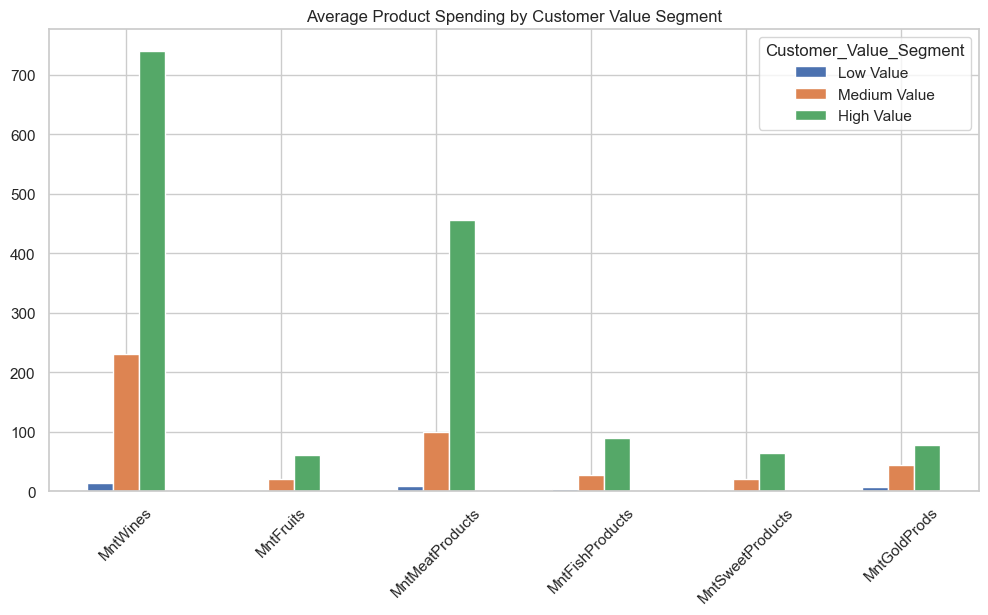

In [58]:
product_by_segment.T.plot(kind='bar', figsize=(12, 6))
plt.title('Average Product Spending by Customer Value Segment')
plt.xticks(rotation=45)
plt.show()

### Interim Insight
Hasil visualisasi pada bagian ini digunakan sebagai dasar untuk insight bisnis dan rekomendasi di akhir notebook.

# 4. Purchase Channel Analysis
Analisis channel pembelian membantu melihat channel mana yang paling dominan.

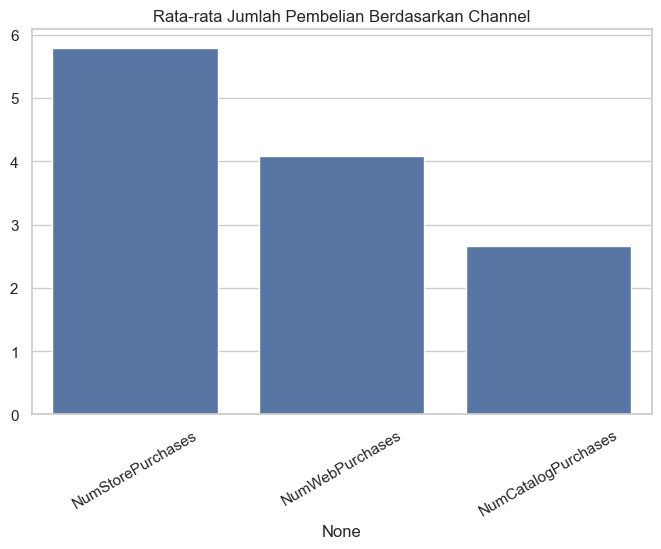

NumStorePurchases      5.794367
NumWebPurchases        4.087170
NumCatalogPurchases    2.662494
dtype: float64

In [59]:
avg_channel = df[purchase_cols].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=avg_channel.index, y=avg_channel.values)
plt.title('Rata-rata Jumlah Pembelian Berdasarkan Channel')
plt.xticks(rotation=30)
plt.show()
avg_channel

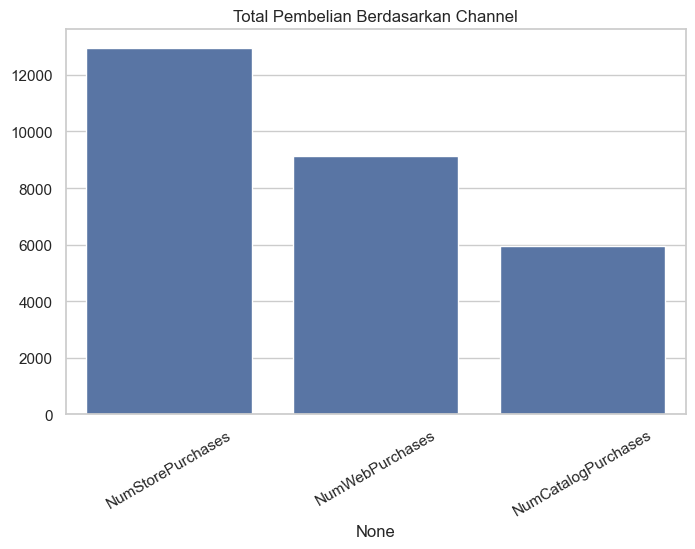

NumStorePurchases      12962
NumWebPurchases         9143
NumCatalogPurchases     5956
dtype: int64

In [60]:
total_channel = df[purchase_cols].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=total_channel.index, y=total_channel.values)
plt.title('Total Pembelian Berdasarkan Channel')
plt.xticks(rotation=30)
plt.show()
total_channel

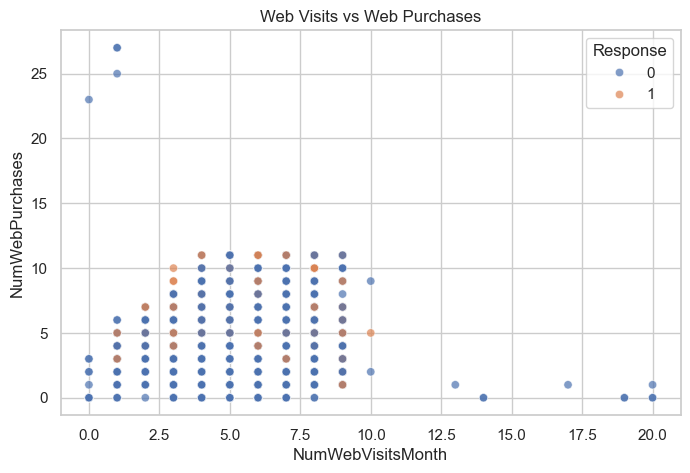

In [61]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='NumWebVisitsMonth', y='NumWebPurchases', hue='Response', alpha=0.7)
plt.title('Web Visits vs Web Purchases')
plt.show()

### Interim Insight
Hasil visualisasi pada bagian ini digunakan sebagai dasar untuk insight bisnis dan rekomendasi di akhir notebook.

# 5. Campaign Response Analysis
Response = 1 berarti customer menerima offer pada campaign terakhir.

In [62]:
response_count = df['Response'].value_counts()
response_rate = df['Response'].value_counts(normalize=True).mul(100).round(2)
display(response_count)
display(response_rate)

Response
0    1903
1     334
Name: count, dtype: int64

Response
0    85.07
1    14.93
Name: proportion, dtype: float64

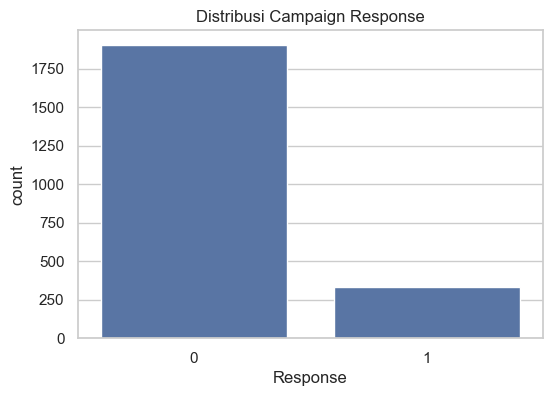

In [63]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Response')
plt.title('Distribusi Campaign Response')
plt.show()

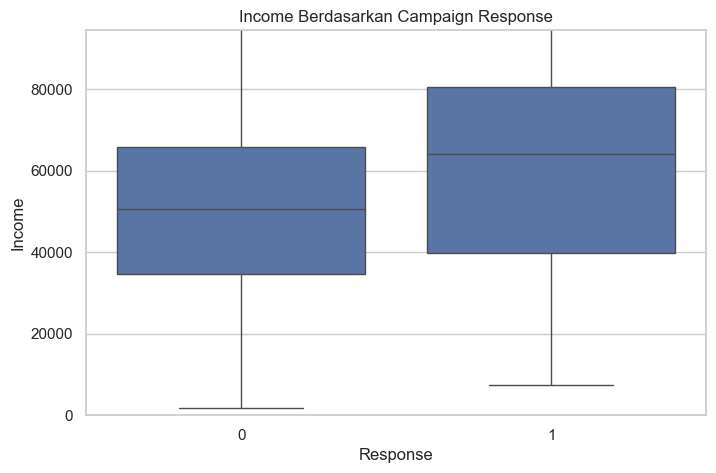

In [64]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Response', y='Income')
plt.ylim(0, df['Income'].quantile(0.99))
plt.title('Income Berdasarkan Campaign Response')
plt.show()

In [65]:
df.groupby('Response')['Income'].agg(['count', 'mean', 'median'])

,count,mean,median
Response,,,
0,1903,50831.060168,50523.0
1,334,60183.244012,64044.0


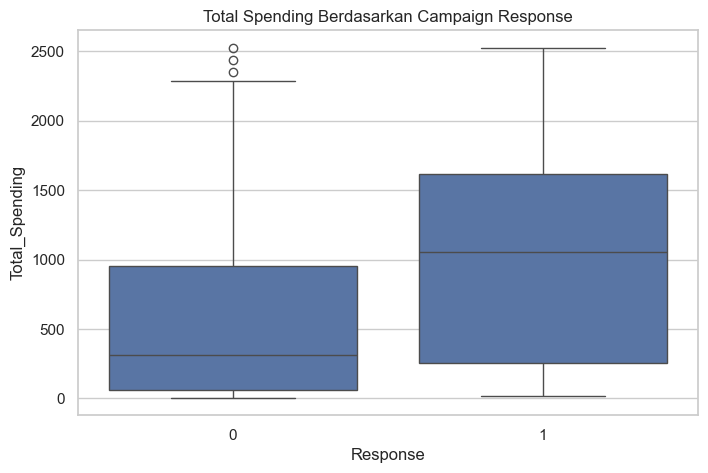

In [66]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Response', y='Total_Spending')
plt.title('Total Spending Berdasarkan Campaign Response')
plt.show()

In [67]:
df.groupby('Response')['Total_Spending'].agg(['count', 'mean', 'median'])

,count,mean,median
Response,,,
0,1903,538.759327,315.0
1,334,987.392216,1057.5


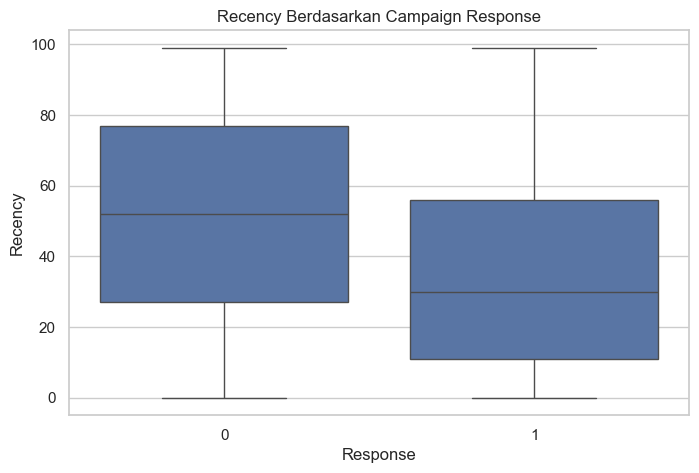

In [68]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Response', y='Recency')
plt.title('Recency Berdasarkan Campaign Response')
plt.show()

In [69]:
df.groupby('Response')['Recency'].agg(['count', 'mean', 'median'])

,count,mean,median
Response,,,
0,1903,51.512874,52.0
1,334,35.383234,30.0


In [70]:
campaign_response_by_education = pd.crosstab(df['Education'], df['Response'], normalize='index').mul(100).round(2)
campaign_response_by_education

Response,0,1
Education,,
2n Cycle,89.05,10.95
Basic,96.30,3.70
Graduation,86.51,13.49
Master,84.59,15.41
PhD,79.18,20.82


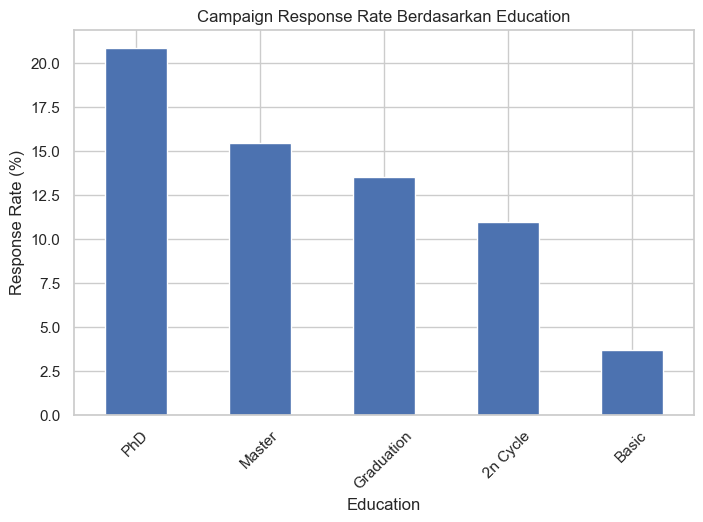

In [71]:
campaign_response_by_education[1].sort_values(ascending=False).plot(kind='bar', figsize=(8, 5))
plt.title('Campaign Response Rate Berdasarkan Education')
plt.ylabel('Response Rate (%)')
plt.xticks(rotation=45)
plt.show()

In [72]:
segment_order = ['Low Value', 'Medium Value', 'High Value']
campaign_response_by_segment = pd.crosstab(df['Customer_Value_Segment'], df['Response'], normalize='index').mul(100).round(2)
campaign_response_by_segment.loc[segment_order]

Response,0,1
Customer_Value_Segment,,
Low Value,94.44,5.56
Medium Value,87.95,12.05
High Value,69.95,30.05


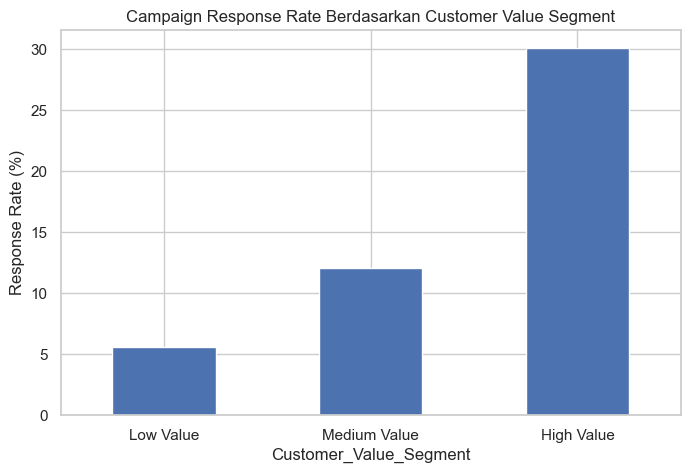

In [73]:
campaign_response_by_segment.loc[segment_order, 1].plot(kind='bar', figsize=(8, 5))
plt.title('Campaign Response Rate Berdasarkan Customer Value Segment')
plt.ylabel('Response Rate (%)')
plt.xticks(rotation=0)
plt.show()

### Interim Insight
Hasil visualisasi pada bagian ini digunakan sebagai dasar untuk insight bisnis dan rekomendasi di akhir notebook.

# 6. Discount Purchase Analysis
NumDealsPurchases menunjukkan jumlah pembelian menggunakan diskon.

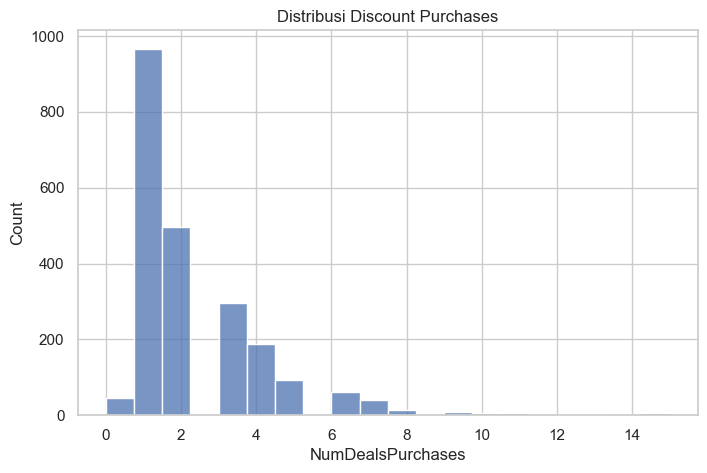

In [74]:
plt.figure(figsize=(8, 5))
sns.histplot(df['NumDealsPurchases'], bins=20, kde=False)
plt.title('Distribusi Discount Purchases')
plt.show()

In [75]:
df['NumDealsPurchases'].describe()

count    2237.000000
mean        2.326777
std         1.932923
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        15.000000
Name: NumDealsPurchases, dtype: float64

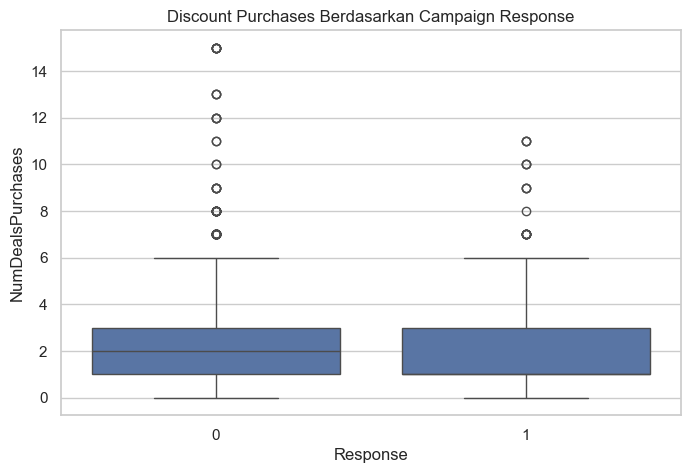

In [76]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Response', y='NumDealsPurchases')
plt.title('Discount Purchases Berdasarkan Campaign Response')
plt.show()

In [77]:
df.groupby('Response')['NumDealsPurchases'].agg(['count', 'mean', 'median'])

,count,mean,median
Response,,,
0,1903,2.325276,2.0
1,334,2.335329,1.0


### Interim Insight
Hasil visualisasi pada bagian ini digunakan sebagai dasar untuk insight bisnis dan rekomendasi di akhir notebook.

# 7. Complain Analysis
Complain menunjukkan apakah customer pernah complain dalam 2 tahun terakhir.

In [78]:
df['Complain'].value_counts(normalize=True).mul(100).round(2)

Complain
0    99.11
1     0.89
Name: proportion, dtype: float64

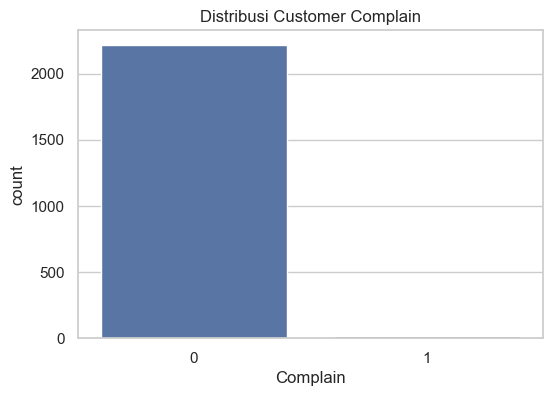

In [79]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Complain')
plt.title('Distribusi Customer Complain')
plt.show()

In [80]:
complain_response = pd.crosstab(df['Complain'], df['Response'], normalize='index').mul(100).round(2)
complain_response

Response,0,1
Complain,,
0,85.07,14.93
1,85.00,15.00


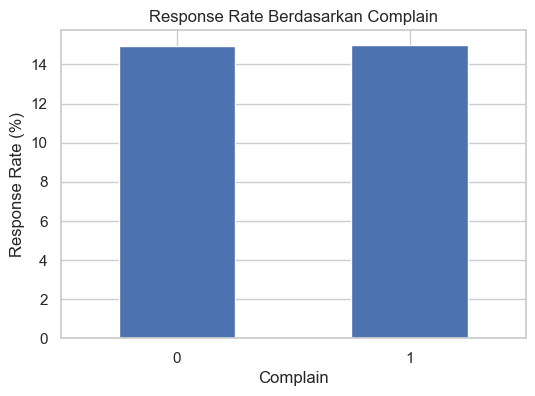

In [81]:
complain_response[1].plot(kind='bar', figsize=(6, 4))
plt.title('Response Rate Berdasarkan Complain')
plt.ylabel('Response Rate (%)')
plt.xticks(rotation=0)
plt.show()

### Interim Insight
Hasil visualisasi pada bagian ini digunakan sebagai dasar untuk insight bisnis dan rekomendasi di akhir notebook.

# 8. Recency Segment Analysis
Recency segment membedakan customer aktif, warm, dan inactive.

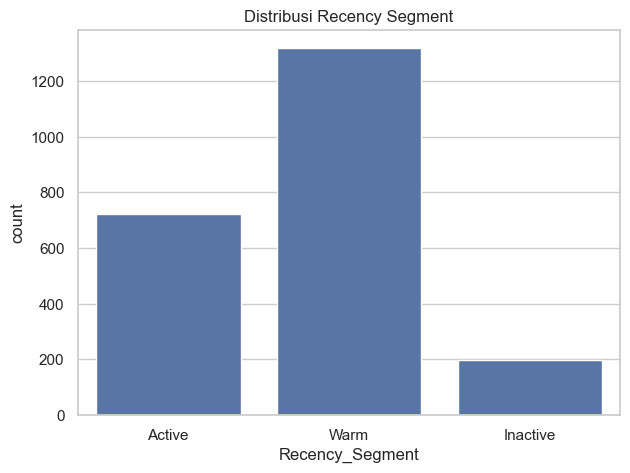

In [82]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Recency_Segment', order=['Active', 'Warm', 'Inactive'])
plt.title('Distribusi Recency Segment')
plt.show()

In [83]:
recency_response = pd.crosstab(df['Recency_Segment'], df['Response'], normalize='index').mul(100).round(2)
recency_response.loc[['Active', 'Warm', 'Inactive']]

Response,0,1
Recency_Segment,,
Active,76.07,23.93
Warm,88.61,11.39
Inactive,94.42,5.58


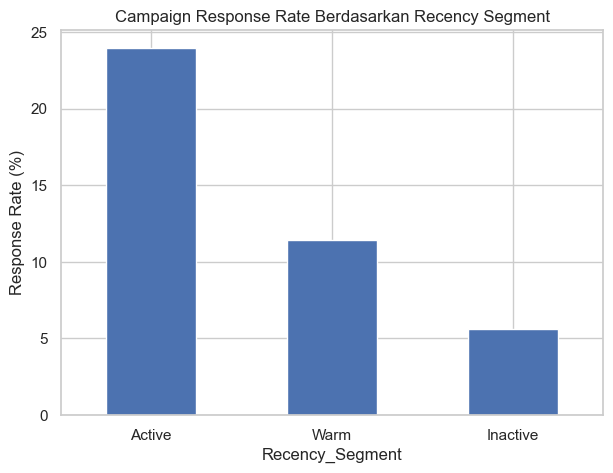

In [84]:
recency_response.loc[['Active', 'Warm', 'Inactive'], 1].plot(kind='bar', figsize=(7, 5))
plt.title('Campaign Response Rate Berdasarkan Recency Segment')
plt.ylabel('Response Rate (%)')
plt.xticks(rotation=0)
plt.show()

### Interim Insight
Hasil visualisasi pada bagian ini digunakan sebagai dasar untuk insight bisnis dan rekomendasi di akhir notebook.

# 9. Customer Value Segment Analysis
Customer value segment membandingkan karakteristik customer berdasarkan spending.

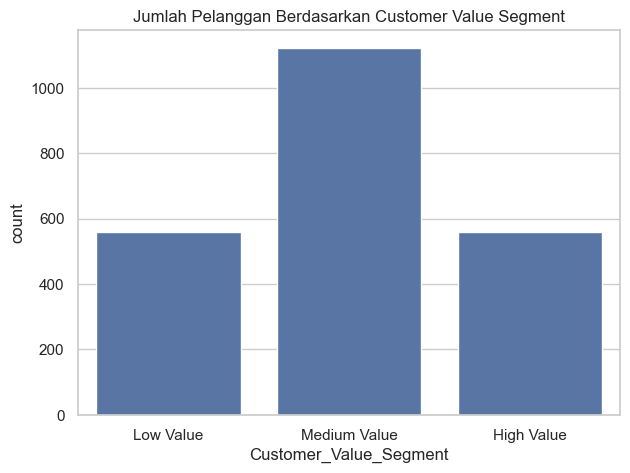

In [85]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Customer_Value_Segment', order=segment_order)
plt.title('Jumlah Pelanggan Berdasarkan Customer Value Segment')
plt.show()

In [86]:
df.groupby('Customer_Value_Segment')[['Income', 'Age', 'Recency', 'Total_Purchases', 'Total_Spending']].agg(['mean', 'median']).loc[segment_order]

Income                 Age           Recency  \
                                mean   median       mean median       mean   
Customer_Value_Segment                                                       
Low Value               32532.556452  30500.0  54.066308   53.0  48.998208   
Medium Value            50647.425446  51258.5  58.165179   57.0  48.722321   
High Value              75052.644007  75236.0  57.987478   57.0  49.976744   

                              Total_Purchases        Total_Spending          
                       median            mean median           mean  median  
Customer_Value_Segment                                                       
Low Value                49.0        4.313620    4.0      39.247312    41.0  
Medium Value             50.0       12.921429   13.0     446.727679   396.0  
High Value               53.0       20.003578   20.0    1489.826476  1440.0

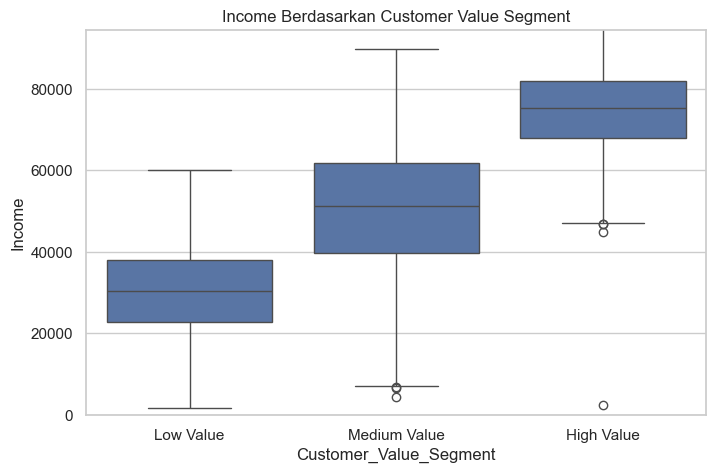

In [87]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Customer_Value_Segment', y='Income', order=segment_order)
plt.ylim(0, df['Income'].quantile(0.99))
plt.title('Income Berdasarkan Customer Value Segment')
plt.show()

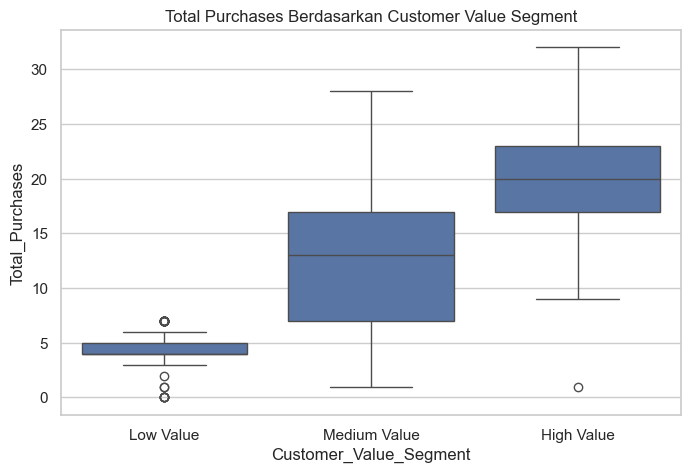

In [88]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Customer_Value_Segment', y='Total_Purchases', order=segment_order)
plt.title('Total Purchases Berdasarkan Customer Value Segment')
plt.show()

### Interim Insight
Hasil visualisasi pada bagian ini digunakan sebagai dasar untuk insight bisnis dan rekomendasi di akhir notebook.

# 10. Correlation Analysis
Correlation analysis melihat hubungan antar variabel numerik.

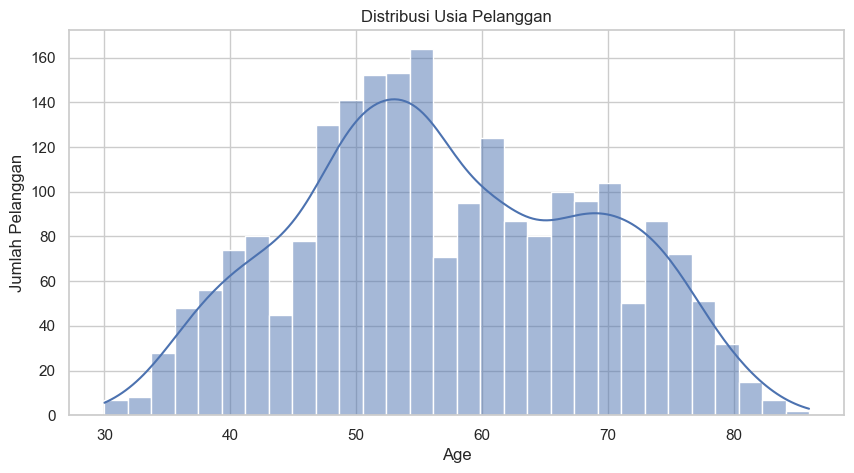

In [89]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Distribusi Usia Pelanggan')
plt.xlabel('Age')
plt.ylabel('Jumlah Pelanggan')
plt.show()

In [90]:
df['Age'].describe()

count    2237.000000
mean       57.098346
std        11.701917
min        30.000000
25%        49.000000
50%        56.000000
75%        67.000000
max        86.000000
Name: Age, dtype: float64

### Insight
Distribusi usia membantu perusahaan memahami kelompok usia dominan pelanggan.

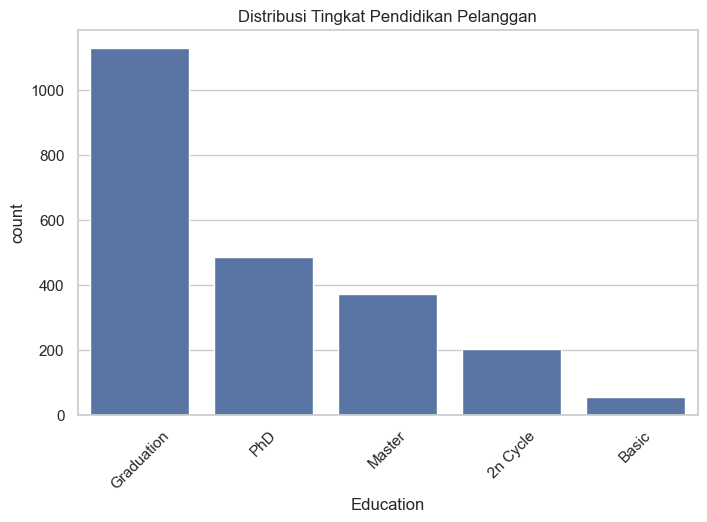

In [91]:
plt.figure(figsize=(8, 5))
order = df['Education'].value_counts().index
sns.countplot(data=df, x='Education', order=order)
plt.title('Distribusi Tingkat Pendidikan Pelanggan')
plt.xticks(rotation=45)
plt.show()

In [92]:
df['Education'].value_counts(normalize=True).mul(100).round(2)

Education
Graduation    50.38
PhD           21.68
Master        16.54
2n Cycle       8.99
Basic          2.41
Name: proportion, dtype: float64

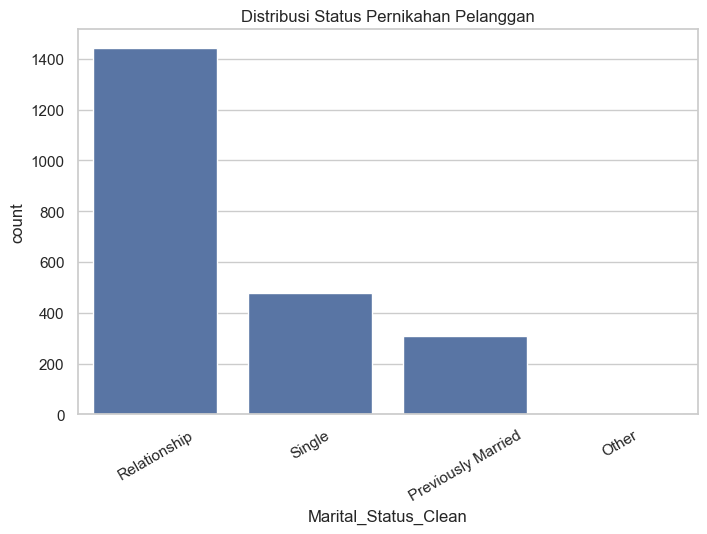

In [93]:
plt.figure(figsize=(8, 5))
order = df['Marital_Status_Clean'].value_counts().index
sns.countplot(data=df, x='Marital_Status_Clean', order=order)
plt.title('Distribusi Status Pernikahan Pelanggan')
plt.xticks(rotation=30)
plt.show()

In [94]:
df['Marital_Status_Clean'].value_counts(normalize=True).mul(100).round(2)

Marital_Status_Clean
Relationship          64.51
Single                21.41
Previously Married    13.77
Other                  0.31
Name: proportion, dtype: float64

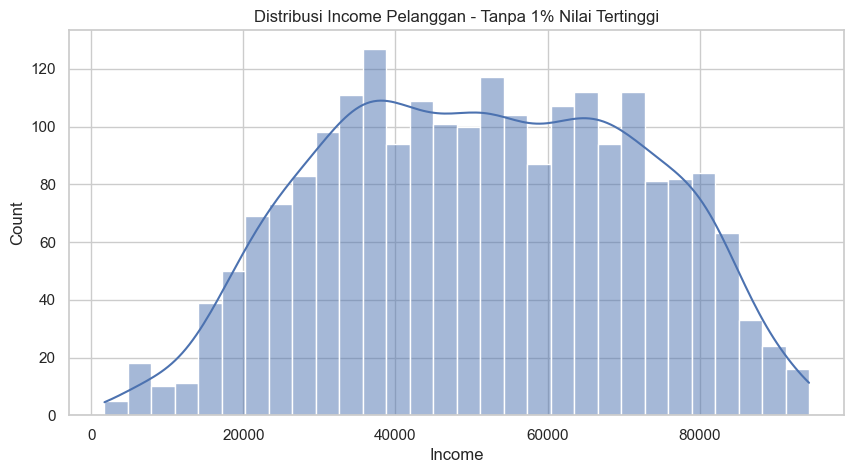

In [95]:
plt.figure(figsize=(10, 5))
sns.histplot(df[df['Income'] < df['Income'].quantile(0.99)]['Income'], bins=30, kde=True)
plt.title('Distribusi Income Pelanggan - Tanpa 1% Nilai Tertinggi')
plt.show()

In [96]:
df['Income'].describe()

count      2237.000000
mean      52227.407689
std       25043.266830
min        1730.000000
25%       35523.000000
50%       51381.500000
75%       68281.000000
max      666666.000000
Name: Income, dtype: float64

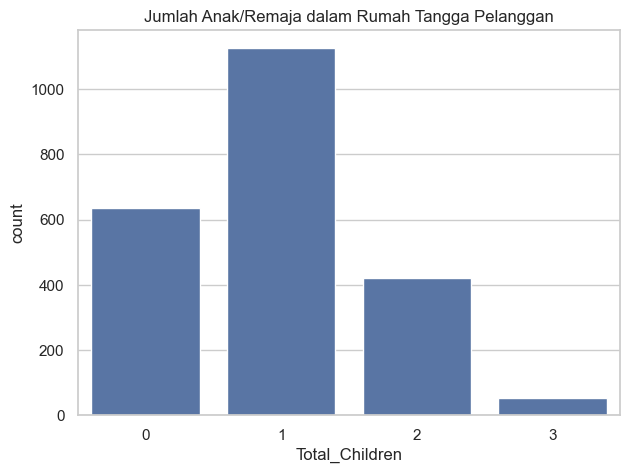

In [97]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Total_Children')
plt.title('Jumlah Anak/Remaja dalam Rumah Tangga Pelanggan')
plt.show()

### Interim Insight
Hasil visualisasi pada bagian ini digunakan sebagai dasar untuk insight bisnis dan rekomendasi di akhir notebook.

# Statistical Analysis

Uji statistik digunakan untuk memvalidasi insight dari visualisasi dan tabel. Level signifikansi yang digunakan adalah 5%.

## Normality Test

In [98]:
for col in ['Income', 'Total_Spending', 'Recency', 'NumDealsPurchases']:
    stat, pvalue = normaltest(df[col])
    print(f'{col}')
    print(f'p-value: {pvalue}')
    if pvalue < 0.05:
        print('Kesimpulan: data tidak berdistribusi normal')
    else:
        print('Kesimpulan: data berdistribusi normal')
    print('-' * 50)

Income
p-value: 0.0
Kesimpulan: data tidak berdistribusi normal
--------------------------------------------------
Total_Spending
p-value: 4.763963378775724e-50
Kesimpulan: data tidak berdistribusi normal
--------------------------------------------------
Recency
p-value: 0.0
Kesimpulan: data tidak berdistribusi normal
--------------------------------------------------
NumDealsPurchases
p-value: 5.747549108372175e-260
Kesimpulan: data tidak berdistribusi normal
--------------------------------------------------


## Mann-Whitney U Test: Total Spending vs Response
Hipotesis:
- H0: Tidak terdapat perbedaan Total_Spending antara customer Response 1 dan Response 0.
- H1: Terdapat perbedaan Total_Spending antara customer Response 1 dan Response 0.

In [99]:
group_yes = df[df['Response'] == 1]['Total_Spending']
group_no = df[df['Response'] == 0]['Total_Spending']
stat, pvalue = mannwhitneyu(group_yes, group_no, alternative='two-sided')
print(f'p-value: {pvalue}')
if pvalue < 0.05:
    print('Tolak H0: Terdapat perbedaan Total Spending yang signifikan berdasarkan Response.')
else:
    print('Gagal tolak H0: Tidak terdapat perbedaan Total_Spending yang signifikan berdasarkan Response.')

p-value: 1.4467523692145714e-29
Tolak H0: Terdapat perbedaan Total Spending yang signifikan berdasarkan Response.


## Mann-Whitney U Test: Income vs Response
Hipotesis:
- H0: Tidak terdapat perbedaan Income antara customer Response 1 dan Response 0.
- H1: Terdapat perbedaan Income antara customer Response 1 dan Response 0.

In [100]:
group_yes = df[df['Response'] == 1]['Income']
group_no = df[df['Response'] == 0]['Income']
stat, pvalue = mannwhitneyu(group_yes, group_no, alternative='two-sided')
print(f'p-value: {pvalue}')
if pvalue < 0.05:
    print('Tolak H0: Terdapat perbedaan Income yang signifikan berdasarkan Response.')
else:
    print('Gagal tolak H0: Tidak terdapat perbedaan Income yang signifikan berdasarkan Response.')

p-value: 3.4079853954095754e-14
Tolak H0: Terdapat perbedaan Income yang signifikan berdasarkan Response.


## Mann-Whitney U Test: Recency vs Response
Hipotesis:
- H0: Tidak terdapat perbedaan Recency antara customer Response 1 dan Response 0.
- H1: Terdapat perbedaan Recency antara customer Response 1 dan Response 0.

In [101]:
group_yes = df[df['Response'] == 1]['Recency']
group_no = df[df['Response'] == 0]['Recency']
stat, pvalue = mannwhitneyu(group_yes, group_no, alternative='two-sided')
print(f'p-value: {pvalue}')
if pvalue < 0.05:
    print('Tolak H0: Terdapat perbedaan Recency yang signifikan berdasarkan Response.')
else:
    print('Gagal tolak H0: Tidak terdapat perbedaan Recency yang signifikan berdasarkan Response.')

p-value: 6.89877494339142e-21
Tolak H0: Terdapat perbedaan Recency yang signifikan berdasarkan Response.


## Chi-Square Test: Education vs Response
Hipotesis:
- H0: Education dan Response tidak memiliki hubungan.
- H1: Education dan Response memiliki hubungan.

In [102]:
contingency = pd.crosstab(df['Education'], df['Response'])
chi2, pvalue, dof, expected = chi2_contingency(contingency)
print(f'p-value: {pvalue}')
if pvalue < 0.05:
    print('Tolak H0: Education memiliki hubungan yang signifikan dengan Response.')
else:
    print('Gagal tolak H0: Education tidak memiliki hubungan yang signifikan dengan Response.')
contingency

p-value: 0.00012361656648398502
Tolak H0: Education memiliki hubungan yang signifikan dengan Response.


Response,0,1
Education,,
2n Cycle,179,22
Basic,52,2
Graduation,975,152
Master,313,57
PhD,384,101


## Chi-Square Test: Customer Value Segment vs Response
Hipotesis:
- H0: Customer Value Segment dan Response tidak memiliki hubungan.
- H1: Customer Value Segment dan Response memiliki hubungan.

In [103]:
contingency = pd.crosstab(df['Customer_Value_Segment'], df['Response'])
chi2, pvalue, dof, expected = chi2_contingency(contingency)
print(f'p-value: {pvalue}')
if pvalue < 0.05:
    print('Tolak H0: Customer Value Segment memiliki hubungan yang signifikan dengan Response.')
else:
    print('Gagal tolak H0: Customer Value Segment tidak memiliki hubungan yang signifikan dengan Response.')
contingency

p-value: 1.490682776710714e-32
Tolak H0: Customer Value Segment memiliki hubungan yang signifikan dengan Response.


Response,0,1
Customer_Value_Segment,,
High Value,391,168
Low Value,527,31
Medium Value,985,135


## Chi-Square Test: Recency Segment vs Response
Hipotesis:
- H0: Recency Segment dan Response tidak memiliki hubungan.
- H1: Recency Segment dan Response memiliki hubungan.

In [104]:
contingency = pd.crosstab(df['Recency_Segment'], df['Response'])
chi2, pvalue, dof, expected = chi2_contingency(contingency)
print(f'p-value: {pvalue}')
if pvalue < 0.05:
    print('Tolak H0: Recency Segment memiliki hubungan yang signifikan dengan Response.')
else:
    print('Gagal tolak H0: Recency Segment tidak memiliki hubungan yang signifikan dengan Response.')
contingency

p-value: 1.689879863198735e-16
Tolak H0: Recency Segment memiliki hubungan yang signifikan dengan Response.


Response,0,1
Recency_Segment,,
Active,550,173
Inactive,186,11
Warm,1167,150


## Chi-Square Test: Complain vs Response
Hipotesis:
- H0: Complain dan Response tidak memiliki hubungan.
- H1: Complain dan Response memiliki hubungan.

In [105]:
contingency = pd.crosstab(df['Complain'], df['Response'])
chi2, pvalue, dof, expected = chi2_contingency(contingency)
print(f'p-value: {pvalue}')
if pvalue < 0.05:
    print('Tolak H0: Complain memiliki hubungan yang signifikan dengan Response.')
else:
    print('Gagal tolak H0: Complain tidak memiliki hubungan yang signifikan dengan Response.')
contingency

p-value: 1.0
Gagal tolak H0: Complain tidak memiliki hubungan yang signifikan dengan Response.


Response,0,1
Complain,,
0,1886,331
1,17,3


## Kruskal-Wallis Test: Total Spending by Education

In [106]:
groups = [group['Total_Spending'].values for name, group in df.groupby('Education')]
stat, pvalue = kruskal(*groups)
print(f'p-value: {pvalue}')
if pvalue < 0.05:
    print('Tolak H0: Terdapat perbedaan Total Spending yang signifikan antar Education group.')
else:
    print('Gagal tolak H0: Tidak terdapat perbedaan Total Spending yang signifikan antar Education group.')

p-value: 2.304136625091932e-14
Tolak H0: Terdapat perbedaan Total Spending yang signifikan antar Education group.


# Business Insight

## Insight: Campaign response rate masih relatif rendah
Campaign belum sepenuhnya tepat sasaran atau belum cukup menarik bagi sebagian besar pelanggan. Campaign perlu dibuat lebih personal.

## Insight: Spending terbesar berasal dari kategori Wine dan Meat
Kategori dengan spending tinggi dapat digunakan sebagai fokus promosi, bundling, upselling, dan loyalty program.

## Insight: High-value customer perlu menjadi prioritas
Customer dengan total spending tinggi memiliki kontribusi revenue lebih besar dan perlu dipertahankan.

## Insight: Store masih menjadi channel pembelian penting
Toko fisik masih penting dalam customer journey, tetapi channel digital tetap perlu dikembangkan.

## Insight: Web visits belum tentu menghasilkan web purchases
Perusahaan perlu mengevaluasi conversion funnel website dan membuat web-exclusive promotion.

## Insight: Discount behavior dapat digunakan untuk strategi campaign
Customer dengan NumDealsPurchases tinggi kemungkinan lebih price-sensitive.

## Insight: Recency segment penting untuk retention dan reactivation
Active, warm, dan inactive customer membutuhkan treatment campaign yang berbeda.

# Actionable Recommendations

## Recommendation: Fokus Campaign pada High Value Customer
Voucher eksklusif, early access, personalized product recommendation, dan loyalty reward.

## Recommendation: Buat Campaign Berbasis Produk Utama
Bundle wine + meat, promo weekend kategori premium, dan cross-selling produk tambahan.

## Recommendation: Tingkatkan Conversion pada Website
Web-exclusive discount, abandoned cart reminder, simplifikasi checkout, dan rekomendasi produk.

## Recommendation: Buat Strategy Berdasarkan Recency Segment
Active untuk upselling, warm untuk reminder, inactive untuk reactivation discount.

## Recommendation: Gunakan Discount Campaign untuk Price-Sensitive Customer
Coupon campaign, buy more save more, dan flash sale untuk customer sensitif harga.

## Recommendation: Perkuat Service Recovery untuk Customer yang Pernah Complain
Follow-up customer service, apology coupon, satisfaction survey, dan priority support.

# Kesimpulan
Analisis menunjukkan bahwa perilaku pelanggan dapat dipahami melalui kombinasi data demografi, spending, channel pembelian, recency, discount behavior, complaint history, dan campaign response. Segmentasi pelanggan dapat membantu perusahaan membuat campaign yang lebih efektif, efisien, dan berfokus pada customer value.

# Export Clean Data for Dashboard

In [107]:
df.to_csv('supermarket_customers_cleaned.csv', index=False)
print('Clean dataset berhasil diexport menjadi supermarket_customers_cleaned.csv')

Clean dataset berhasil diexport menjadi supermarket_customers_cleaned.csv
